# Transects and transport

This notebook demonstrates 

* how to define an oceanographic section,
* compute volume, heat, salt and freshwater transports through HYCOM output,
* visualise the spatial structure of transport across the section.

**Functions covered**

| Function | Purpose |
|---|---|
| `xhycom.Transect` | Define a section from (lon, lat) waypoints |
| `Transect.resolve(grid)` | Snap the section to the HYCOM C-grid |
| `Transect.reverse()` | Flip the sign convention by reversing waypoint order |
| `xhycom.transport()` | Volume / heat / salt / freshwater transport through HYCOM |
| `xhycom.section_data()` | Hydrographic cross-section (T-point fields) |
| `xhycom.section_flux_density()` | Per-face, per-layer transport density |
| `xhycom.section_plot()` | 2-D section visualisation |

**See also:** [comparison_transects_transports.ipynb](comparison_transects_transports.ipynb) — comparing these HYCOM results against GLORYS using different strategies.

In [1]:
import numpy as np
import xarray as xr
import xhycom
import matplotlib.pyplot as plt

In [2]:
GRID_PATH = "/cluster/home/nlo043/NERSC-HYCOM-CICE/TP2a0.10/topo/regional.grid"
BATHY_PATH = "/cluster/home/nlo043/NERSC-HYCOM-CICE/TP2a0.10/topo/depth_TP2a0.10_01"
DATA_PATH = "/nird/datalake/NS9481K/shuang/TP2_output/expt_02.8/"

In [3]:
grid = xhycom.open_dataset(GRID_PATH)
bathy = xhycom.open_dataset(BATHY_PATH, grid=GRID_PATH)

## 1. Define and resolve a transect

A `Transect` is a sequence of (lon, lat) waypoints and knows nothing about any particular model grid — the same object can be resolved against any grid, including any HYCOM and any lat-lon grid.

> **Grid terminology** — HYCOM uses an Arakawa C-grid: a staggered arrangement where different quantities live at different locations within each nominal grid cell.
> - **T-cell** (tracer cell): the basic grid cell, indexed by `(j, i)`.  Scalars — temperature, salinity, layer thickness, sea-surface height — are stored at its centre.
> - **U-face**: the west face of T-cell `(j, i)`, where the zonal (x-direction) velocity component is stored.
> - **V-face**: the south face of T-cell `(j, i)`, where the meridional (y-direction) velocity component is stored.
>
> Because each velocity component lives exactly at its own face it is already normal to that face — no rotation is needed to obtain face-normal transport.

Calling `Transect.resolve(grid)` does two things:

- **T-cell path**: the ordered T-cells the section polyline passes through, used by `section_data` to extract hydrographic fields.
- **C-grid faces**: the exact U- and V-face crossings used by `transport` and `section_flux_density`.

### How face identification works (MSCPROGS method)

A transect with N waypoints defines N−1 straight segments.  The algorithm processes every segment in turn: for each pair of consecutive waypoints it divides the model grid into two hemispheres using the great-circle plane through those two points.  A vectorised telescopic sum of the resulting Boolean mask places ±1 flags at every U- or V-face that lies on the great-circle boundary between the hemispheres:

```
flagu[j, i] = mask[j, i] - mask[j, i-1]   # west face of T[j,i], carries u-vel
flagv[j, i] = mask[j, i] - mask[j-1, i]   # south face of T[j,i], carries v-vel
```

Faces outside the segment's extent are clipped; the sign of each flag encodes the transport direction (positive = rightward, matching the waypoint order).  Faces from all N−1 segments are then combined into a single ordered list.

This is the same algorithm used in the [NERSC MSCPROGS](https://github.com/nansencenter/NERSC-HYCOM-CICE/tree/develop/hycom/MSCPROGS) implementation.

Several common Arctic and sub-Arctic sections are built in:

In [4]:
# Available named sections
xhycom.Transect.available_names()

['barents_kara_northern_boundary',
 'barents_opening',
 'bering_strait',
 'davis_strait',
 'denmark_strait',
 'fram_strait',
 'fsc',
 'gimsoy',
 'hudson_strait',
 'jones_strait',
 'kara_gate',
 'kola_section',
 'lancaster_sound',
 'robeson_channel',
 'svinoy']

Use `Transect.named()` to retrieve a built-in section:

In [5]:
fs = xhycom.Transect.named("fram_strait")
fs

Transect('fram_strait', 2 waypoints)

Built-in zonal sections are defined east → west, so positive transport is northward.  The Fram Strait waypoints are:

In [6]:
fs.lons

array([ 15., -20.])

In [7]:
fs.lats

array([79., 79.])

> **Sign convention** — positive transport is **rightward** when walking from the first to the last waypoint.
>
> Built-in zonal sections are defined east → west, so north is on your right and positive means northward:
>
> | Sign | Physical meaning at Fram Strait |
> |---|---|
> | positive | northward — Atlantic inflow (West Spitsbergen Current) |
> | negative | southward — Arctic outflow (East Greenland Current) |
>
> Call `fs.reverse()` to adopt the opposite convention (positive = southward).

You can also pass waypoints directly.  The sign convention is set entirely by their order — the example below uses the original west-to-east orientation (positive = southward), which shows both conventions are equally valid:

In [8]:
custom = xhycom.Transect(lons=[-20, 15], lats=[79, 79], name="My Fram Strait")
custom

Transect('My Fram Strait', 2 waypoints)

Now resolve against the HYCOM grid.  This is the step that ties the section geometry to a specific model grid.  The resolved object stores the T-cell path, face indices, face signs, and along-section distances — everything needed for transport and section-data calculations.

**Resolve once, reuse many times**: `resolve()` builds a KD-tree over the full T-point grid and should be called once per grid.  Pass the `ResolvedTransect` to all subsequent `transport()`, `section_data()`, and `section_flux_density()` calls.

The three plots below show the section at increasing zoom: the full domain view, a regional view around Fram Strait, and a close-up where individual T-cells and the U/V face staircase are visible.

In [9]:
fs_on_hycom = fs.resolve(grid)

In [10]:
print(f"T-cells along section : {fs_on_hycom.n_cells}")
print(f"C-grid faces crossed  : {fs_on_hycom.n_faces}")
print(f"Section length        : {fs_on_hycom.distance_km[-1]:.0f} km")

T-cells along section : 54
C-grid faces crossed  : 54
Section length        : 978 km


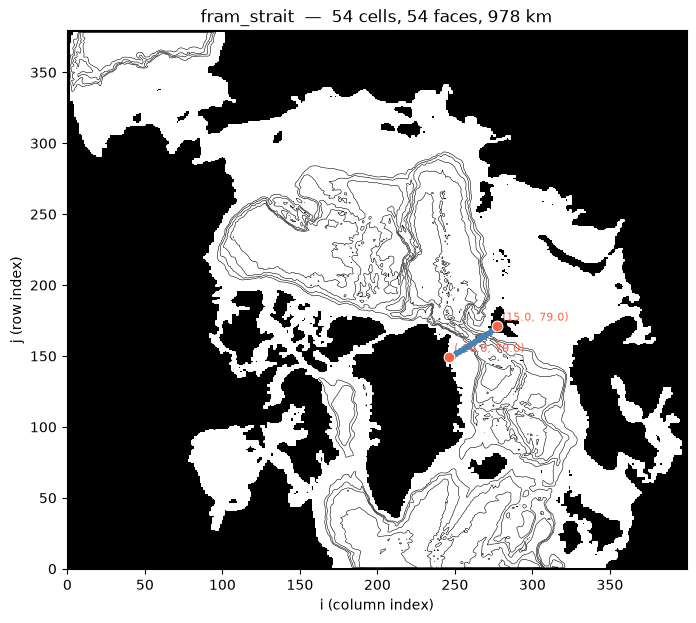

In [11]:
fs_on_hycom.plot(grid=grid, bathy=bathy, figsize=(8, 7))

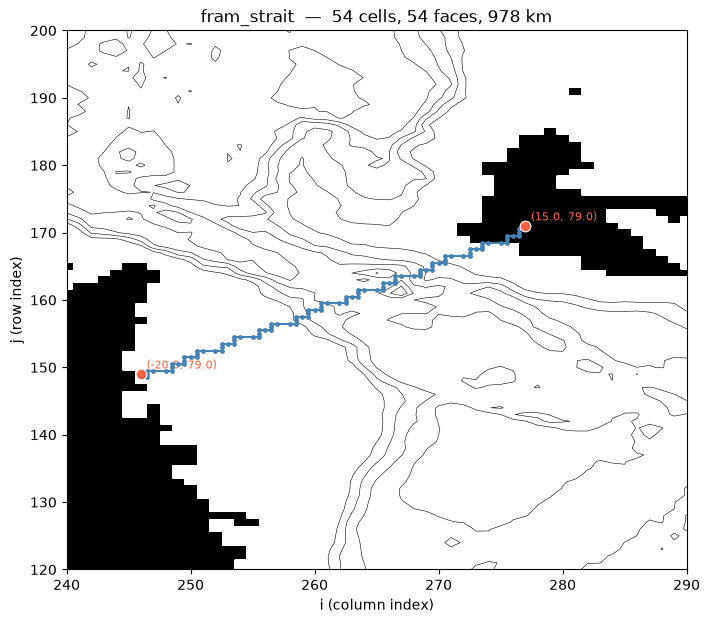

In [12]:
fs_on_hycom.plot(grid=grid, bathy=bathy, i_range=(240, 290), j_range=(120, 200), figsize=(8, 7))

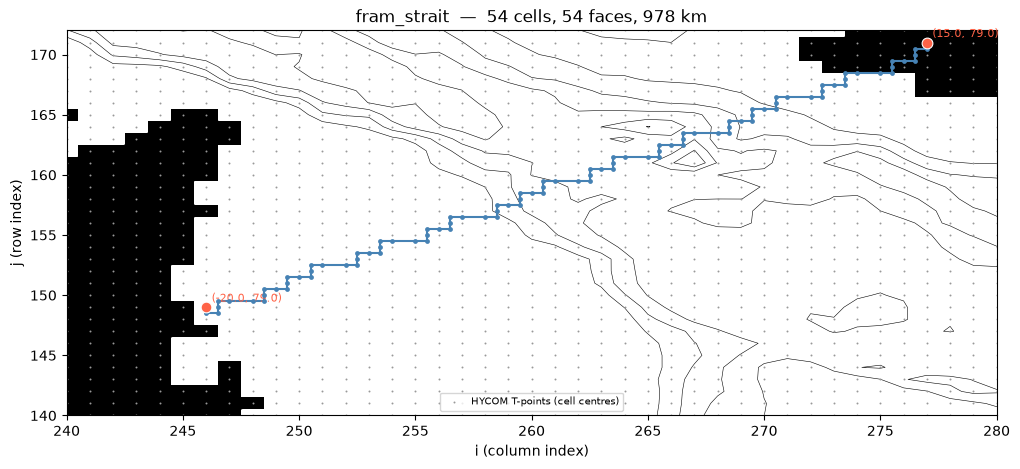

In [13]:
fs_on_hycom.plot(grid=grid, bathy=bathy, show_cells=True, i_range=(240, 280), j_range=(140, 172), figsize=(12, 5))

Here is a plot of all pre-defined sections resolved on the TOPAZ 2 grid.

In [14]:
named_resolved = {
    name: xhycom.Transect.named(name).resolve(grid)
    for name in xhycom.Transect.available_names()
}

In [15]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

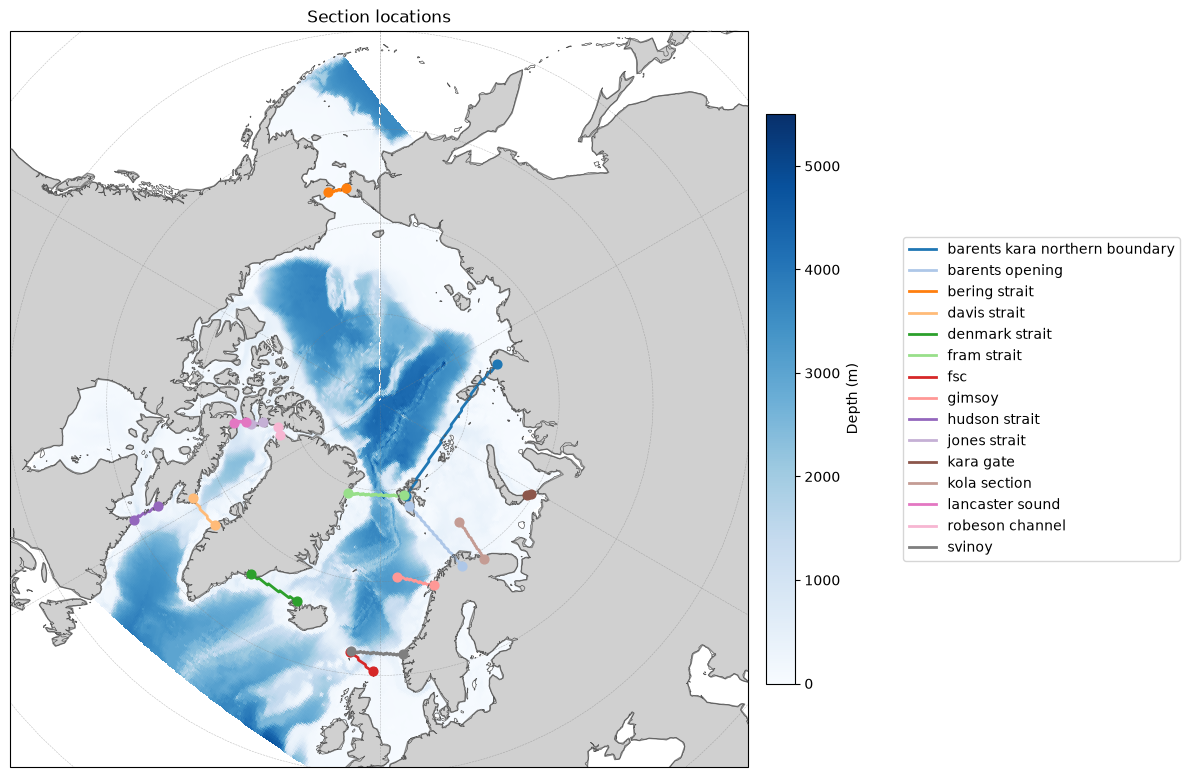

In [16]:
proj = ccrs.NorthPolarStereo(central_longitude=0.0)
fig, ax = plt.subplots(figsize=(12, 10), subplot_kw={"projection": proj})
ax.set_extent([-180, 180, 50, 90], crs=ccrs.PlateCarree())

lon = bathy.lon.values
lat = bathy.lat.values
depth = bathy["depth"].copy()

# mask cells that straddle the dateline — their huge lon jump causes pcolormesh
# to paint a cross-domain slab that bleeds into NaN (out-of-domain) areas
dlon_x = np.diff(lon, axis=1)
dlon_y = np.diff(lon, axis=0)
bad_wrap = np.zeros(lon.shape, dtype=bool)
bad_wrap[:, 1:]  |= np.abs(dlon_x) > 180
bad_wrap[:, :-1] |= np.abs(dlon_x) > 180
bad_wrap[1:, :]  |= np.abs(dlon_y) > 180
bad_wrap[:-1, :] |= np.abs(dlon_y) > 180
depth = depth.where(~xr.DataArray(bad_wrap, dims=depth.dims))

cmap = plt.cm.Blues.copy()
cmap.set_bad("none")
pcm = ax.pcolormesh(
    lon, lat, depth.values,
    transform=ccrs.PlateCarree(),
    cmap=cmap, vmin=0, vmax=5500, shading="nearest", zorder=1,
)
plt.colorbar(pcm, ax=ax, shrink=0.6, pad=0.02, label="Depth (m)")

ax.add_feature(cfeature.LAND, facecolor="#d0d0d0", edgecolor="#888", zorder=2)
ax.add_feature(cfeature.COASTLINE.with_scale("50m"), edgecolor="#555", linewidth=0.5, zorder=3)
ax.gridlines(linewidth=0.4, linestyle="--", color="grey", alpha=0.5)

colors = plt.cm.tab20.colors
for idx, (name, rt) in enumerate(named_resolved.items()):
    col = colors[idx % len(colors)]
    ax.plot(rt.cell_lon, rt.cell_lat, transform=ccrs.PlateCarree(),
            color=col, lw=2, label=name.replace("_", " "))
    ax.scatter(rt.cell_lon[[0, -1]], rt.cell_lat[[0, -1]],
               transform=ccrs.PlateCarree(), color=col, s=40, zorder=5)

ax.legend(loc="center left", bbox_to_anchor=(1.2, 0.5))
ax.set_title("Section locations", fontsize=12)
plt.tight_layout()

## 2. Volume, heat, salt and freshwater transport

All four quantities are section-normal integrals of the form

$$T = \iint_{\mathcal{S}} f(v_\perp, \theta) \; dz \; dl$$

where $v_\perp$ is the velocity component normal to the section, $dz$ is layer thickness, and $dl$ is the along-section width element.  The four integrands are:

| Transport | Formula | Default params | Unit |
|---|---|---|---|
| Volume | $v_\perp$ | — | Sv |
| Heat | $\rho_0 c_p \,(T - T_\mathrm{ref})\, v_\perp$ | $\rho_0 = 1025\ \mathrm{kg\,m^{-3}}$, $c_p = 3996\ \mathrm{J\,kg^{-1}\,K^{-1}}$, $T_\mathrm{ref} = 0\ ^\circ\mathrm{C}$ | TW |
| Salt | $\dfrac{\rho_0}{1000}\, S\, v_\perp$ | $\rho_0 = 1025\ \mathrm{kg\,m^{-3}}$ | kg s⁻¹ |
| Freshwater | $\dfrac{S_\mathrm{ref} - S}{S_\mathrm{ref}}\, v_\perp$ | $S_\mathrm{ref} = 34.8\ \mathrm{PSU}$ | Sv |

The $\rho_0/1000$ factor in salt converts salinity from PSU (g kg⁻¹) to a mass fraction.  On the HYCOM C-grid the integral is evaluated exactly at the staggered face locations — no interpolation of velocities to T-points — with layer thickness and tracer values averaged from the two T-cells straddling each face.

In [17]:
ds = xhycom.open_mfdataset(DATA_PATH + "archm.2020*", grid=GRID_PATH, chunks={"time": 1}, postprocess=True)

`transport()` integrates velocity and tracer fields over the resolved C-grid faces.

**Why no velocity rotation is needed on HYCOM output.**  HYCOM stores `u-vel.` exactly at U-faces and `v-vel.` exactly at V-faces.  On the Arakawa C-grid, `u-vel.` at face `(j, i)` is by definition the velocity component *normal* to that face (i.e. in the model's local x-direction); the same holds for `v-vel.` at V-faces.  Because `resolve()` identifies exactly which U-faces and V-faces the section crosses — and the sign flag tells it which direction is "rightward" — the transport is an exact face-normal integral with no approximation.

**Tracers and thickness.**  Temperature, salinity, and layer thickness are not stored at faces but at T-cell centres.  `transport()` averages the two T-cells straddling each face to obtain face-centred values.  This is the standard C-grid approximation; it introduces no bias for slowly varying fields.

> **Always postprocess** — open HYCOM archives with `postprocess=True` or call `xhycom.postprocess(ds)` explicitly.  Without it, `u-vel.` contains only the baroclinic component and transports will be wrong. Luckily, `transport()` raises a `ValueError` if it detects baroclinic-only velocities (i.e. `postprocess` was not applied to an `archv` file and the barotropic component is still separate).

> **Thickness units** — `thknss` is stored in Pa in HYCOM archives.  `transport()` and `section_data()` auto-detect the unit and convert to metres internally, so either form works.

In [18]:
%time tr = xhycom.transport(ds, fs_on_hycom)

CPU times: user 1.58 s, sys: 16.7 ms, total: 1.6 s
Wall time: 1.83 s


The result is a small `xr.Dataset` with one scalar time series per transport variable. Note that the call returns instantly because all arrays are Dask-backed — no data has been computed yet.  Computation is deferred until explicitly requested.

In [19]:
tr

<xarray.Dataset> Size: 15kB
Dimensions:  (time: 366)
Coordinates:
  * time     (time) object 3kB 2020-01-01 00:00:00 ... 2020-12-31 00:00:00
Data variables:
    volume   (time) float64 3kB dask.array<chunksize=(1,), meta=np.ndarray>
    heat     (time) float64 3kB dask.array<chunksize=(1,), meta=np.ndarray>
    salt     (time) float64 3kB dask.array<chunksize=(1,), meta=np.ndarray>
    fw       (time) float64 3kB dask.array<chunksize=(1,), meta=np.ndarray>

Loading all four transport variables for a full year triggers the actual computation.  Wall time scales with the number of time steps; chunking by time (as done above) keeps memory usage low.

In [20]:
%time tr.load()

CPU times: user 2min 23s, sys: 1min 15s, total: 3min 39s
Wall time: 1min 35s


<xarray.Dataset> Size: 15kB
Dimensions:  (time: 366)
Coordinates:
  * time     (time) object 3kB 2020-01-01 00:00:00 ... 2020-12-31 00:00:00
Data variables:
    volume   (time) float64 3kB -5.595 -9.257 2.219 ... -4.138 -3.689 0.8378
    heat     (time) float64 3kB 37.08 41.61 40.67 30.3 ... 48.71 37.83 37.89
    salt     (time) float64 3kB -1.96e+08 -3.274e+08 ... -1.298e+08 3.189e+07
    fw       (time) float64 3kB -0.09979 -0.07789 -0.08255 ... -0.05133 -0.05632

In [22]:
def _rolling_mean(da, window=30):
    """Centred rolling mean; min_periods=1 avoids NaNs at section edges."""
    return da.rolling(time=window, center=True, min_periods=1).mean()


_TRANSPORT_LAYOUT = [
    ("volume", "Volume",     "Sv",     (0, 0)),
    ("heat",   "Heat",       "TW",     (0, 1)),
    ("salt",   "Salt",       "kg s\u207b\u00b9", (1, 0)),
    ("fw",     "Freshwater", "Sv",     (1, 1)),
]


def plot_transports(axs, datasets, labels=None, colors=None, rolling=30):
    """Plot volume / heat / salt / fw transports on a 2x2 axes grid.

    Parameters
    ----------
    axs      : (2, 2) array of matplotlib Axes
    datasets : list of xr.Dataset, each with volume / heat / salt / fw variables
    labels   : list of str, one per dataset \u2014 if given, a legend is added
    colors   : list of colour specs, one per dataset \u2014 None entries auto-cycle
    rolling  : centred rolling-mean window in time steps; 0 to disable
               (when enabled, daily values are shown faint and the mean is bold)
    """
    for var, title, unit, pos in _TRANSPORT_LAYOUT:
        ax = axs[pos]
        for i, ds in enumerate(datasets):
            da    = ds[var]
            lbl   = labels[i] if labels else None
            color = colors[i] if colors else None
            if rolling:
                raw_kw = dict(alpha=0.25, lw=0.8, label="_nolegend_")
                if color:
                    raw_kw["color"] = color
                lines = da.plot(ax=ax, **raw_kw)
                rm_kw = dict(lw=2, color=lines[0].get_color())
                if lbl:
                    rm_kw["label"] = lbl
                _rolling_mean(da, rolling).plot(ax=ax, **rm_kw)
            else:
                kw = dict(lw=1.5)
                if color: kw["color"] = color
                if lbl:   kw["label"] = lbl
                da.plot(ax=ax, **kw)
        ax.set_title(f"{title} ({unit})")
        ax.set_ylabel(unit)
        ax.set_xlabel("")
        ax.grid(True, lw=0.4)
        if labels:
            ax.legend()
    plt.tight_layout()

Here are all 4 computed transports, together with a 30-day rolling mean.

Text(0.5, 1.05, 'Transports through Fram Strait')

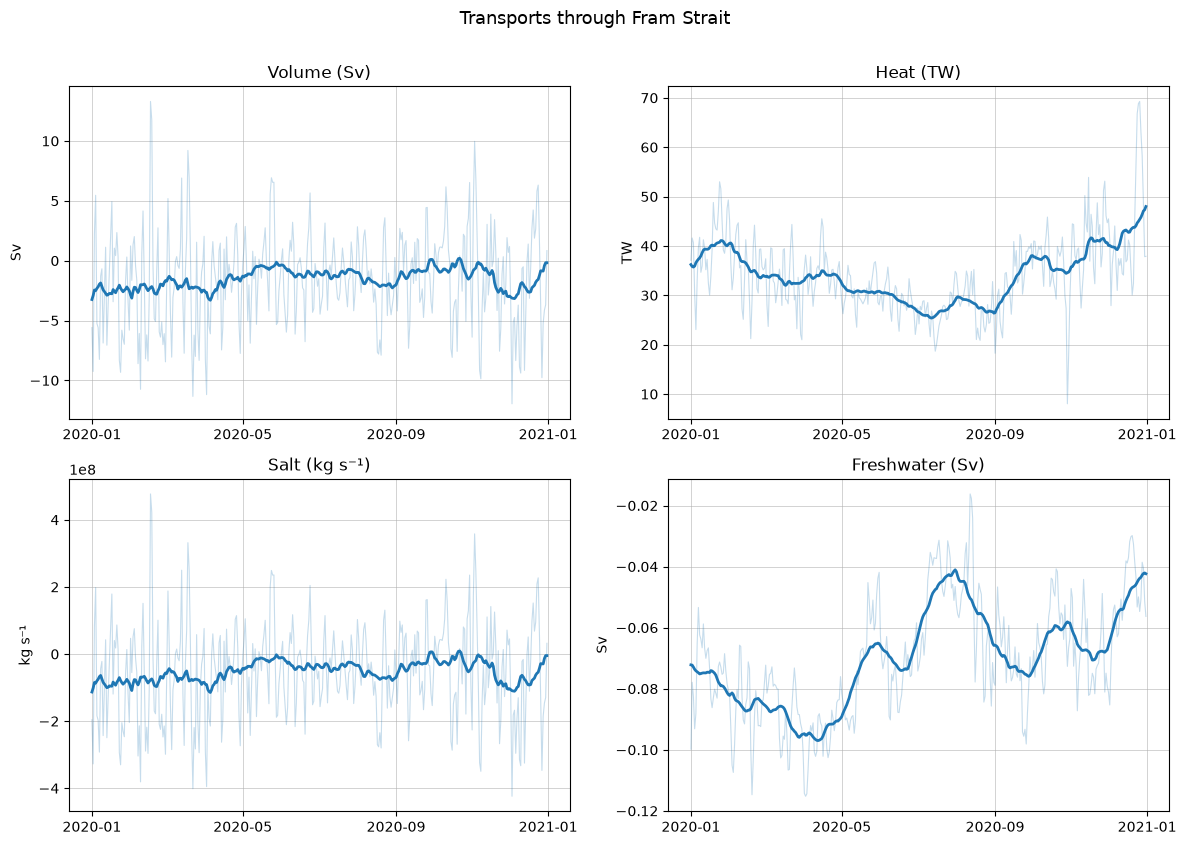

In [27]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
plot_transports(axs, [tr])
fig.suptitle("Transports through Fram Strait", fontsize=13, y=1.05)

### Constrained transports — separating water masses

Pass `constraints` to zero out face-layer contributions where a tracer condition is not met.  Multiple constraints are AND-ed.  The tracer value at each face is the average of the two neighbouring T-cells.

This cleanly separates inflow and outflow by water-mass class.  By construction the constrained transports sum to the total: `tr_aw + tr_pw ≈ tr`.

In [24]:
%%time

# Atlantic Water: T > 1 °C
tr_aw = xhycom.transport(ds, fs_on_hycom, constraints={"temp": ("gt", 1.0)}).compute()
# Polar/Arctic Water: T ≤ 1 °C
tr_pw = xhycom.transport(ds, fs_on_hycom, constraints={"temp": ("le", 1.0)}).compute()

CPU times: user 5min 5s, sys: 1min 45s, total: 6min 50s
Wall time: 3min 11s


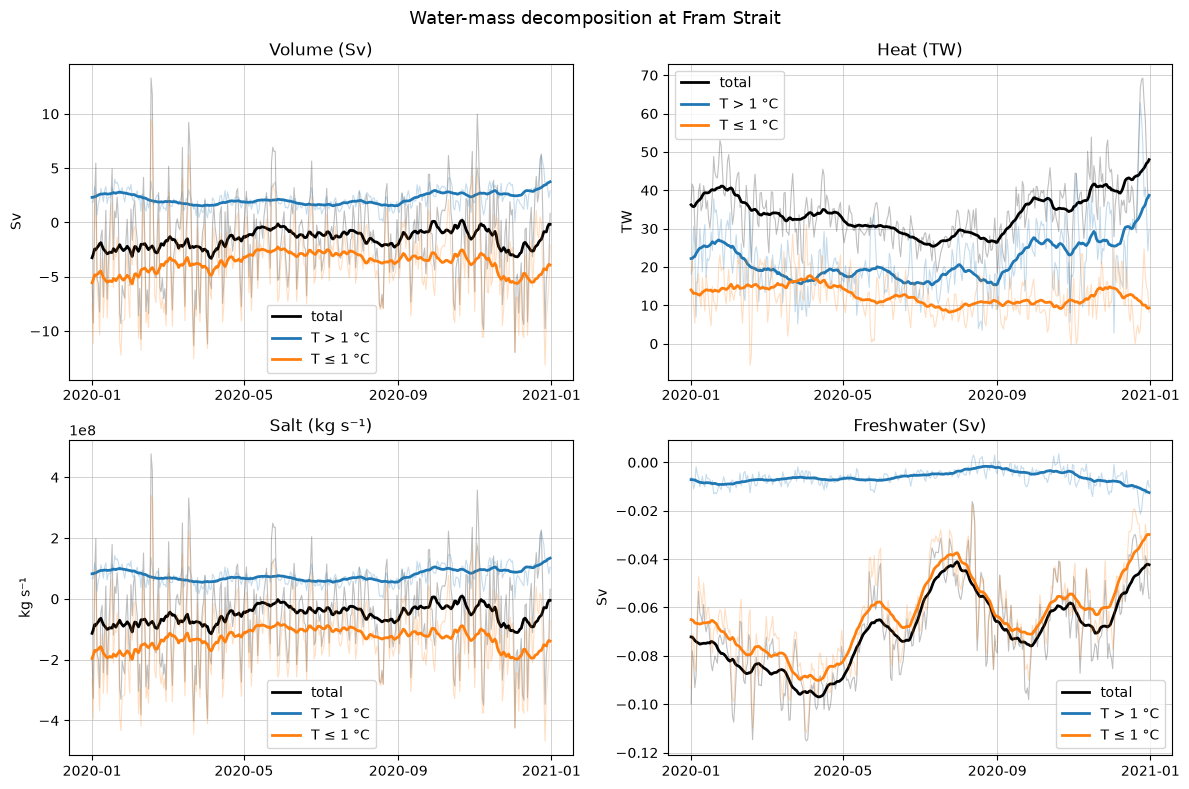

In [25]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
plot_transports(
    axs,
    [tr, tr_aw, tr_pw],
    labels=["total", "T > 1 °C", "T ≤ 1 °C"],
    colors=["k", None, None],
)
fig.suptitle("Water-mass decomposition at Fram Strait", fontsize=13)
plt.tight_layout()

---

## 3. Hydrographic cross-section

`section_data()` extracts any model variable along the T-cell path, returning a `(section, k)` Dataset with `distance_km` and `depth_m` coordinates ready for cross-section plots.  The `section` dimension spans the T-cells identified by `resolve()`; `distance_km` is the cumulative great-circle distance from the first T-cell.

> **Variable selection** — by default `section_data()` extracts every variable in the dataset.  Pass `variables=["temp", "salin"]` to load only what you need — important for large archives.

In [28]:
sec = xhycom.section_data(ds, fs_on_hycom)
sec

<xarray.Dataset> Size: 424MB
Dimensions:      (section: 54, time: 366, k: 50, ki: 51)
Coordinates:
    lon          (section) float64 432B dask.array<chunksize=(54,), meta=np.ndarray>
    lat          (section) float64 432B dask.array<chunksize=(54,), meta=np.ndarray>
    lon_u        (section) float64 432B dask.array<chunksize=(54,), meta=np.ndarray>
    lat_u        (section) float64 432B dask.array<chunksize=(54,), meta=np.ndarray>
    lon_v        (section) float64 432B dask.array<chunksize=(54,), meta=np.ndarray>
    lat_v        (section) float64 432B dask.array<chunksize=(54,), meta=np.ndarray>
    distance_km  (section) float64 432B 0.0 18.21 36.42 ... 940.8 959.4 978.1
  * time         (time) object 3kB 2020-01-01 00:00:00 ... 2020-12-31 00:00:00
  * k            (k) int64 400B 1 2 3 4 5 6 7 8 9 ... 42 43 44 45 46 47 48 49 50
    dens         (k) float64 400B dask.array<chunksize=(50,), meta=np.ndarray>
  * ki           (ki) int64 408B 0 1 2 3 4 5 6 7 8 ... 43 44 45 46 47 48 49 50
Dimensions without coordinates: section
Data variables: (12/84)
    montg1       (time, section) float64 158kB dask.array<chunksize=(1, 54), meta=np.ndarray>
    srfhgt       (time, section) float64 158kB dask.array<chunksize=(1, 54), meta=np.ndarray>
    oneta        (time, section) float64 158kB dask.array<chunksize=(1, 54), meta=np.ndarray>
    surflx       (time, section) float64 158kB dask.array<chunksize=(1, 54), meta=np.ndarray>
    wtrflx       (time, section) float64 158kB dask.array<chunksize=(1, 54), meta=np.ndarray>
    salflx       (time, section) float64 158kB dask.array<chunksize=(1, 54), meta=np.ndarray>
    ...           ...
    ECO_bots     (time, section) float64 158kB dask.array<chunksize=(1, 54), meta=np.ndarray>
    surface__1   (time, section) float64 158kB dask.array<chunksize=(1, 54), meta=np.ndarray>
    surface__2   (time, section) float64 158kB dask.array<chunksize=(1, 54), meta=np.ndarray>
    si_u         (time, section) float64 158kB dask.array<chunksize=(1, 54), meta=np.ndarray>
    si_v         (time, section) float64 158kB dask.array<chunksize=(1, 54), meta=np.ndarray>
    depth_m      (time, k, section) float64 8MB dask.array<chunksize=(1, 50, 54), meta=np.ndarray>

In [29]:
sec0 = sec.isel(time=0)

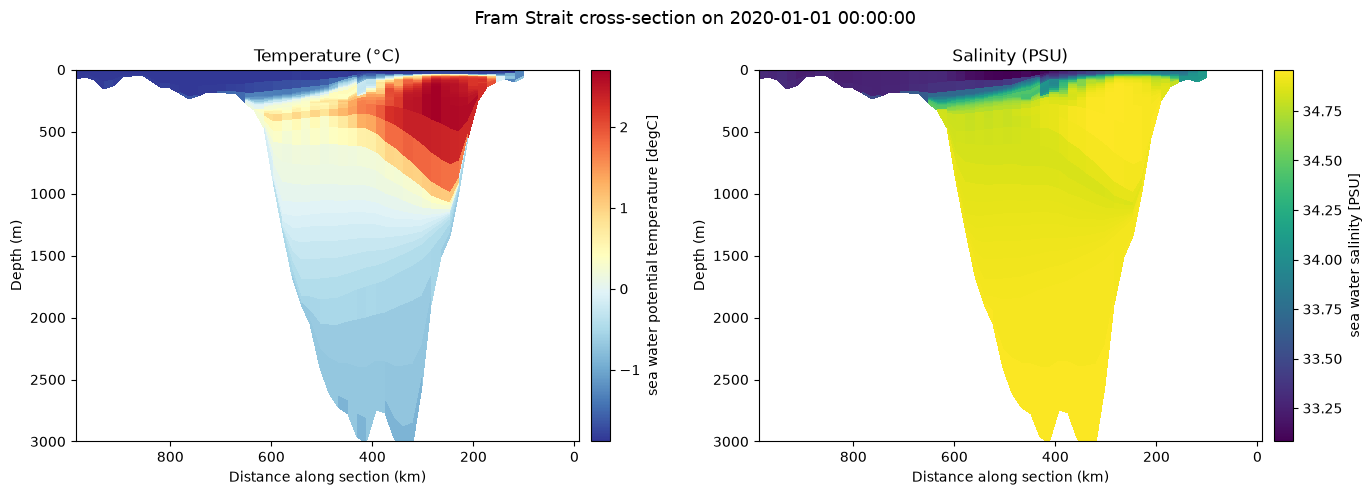

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

xhycom.section_plot(
    sec0, "temp", 
    ax=axes[0],
    cmap="RdYlBu_r",
    depth_max=3000,
    flip_x=True, # flip section orientation to west to east
    title="Temperature (°C)"
)

xhycom.section_plot(
    sec0, "salin", 
    ax=axes[1],
    cmap="viridis",
    depth_max=3000,
    flip_x=True, # flip section orientation to west to east
    title="Salinity (PSU)"
)

fig.suptitle(f"Fram Strait cross-section on {sec0.time.values.item()}", fontsize=13)
plt.tight_layout()

> **x-axis orientation** — the x-axis runs from east (left, 0 km) to west (right, ~1035 km), matching the east → west waypoint order of the built-in Fram Strait transect.  To show the Fram Strait with west on the left in the above plot, we passed `flip_x=True` to `section_plot`.

---

## 4. Transport structure — where does the transport come from?

`section_flux_density()` returns the **signed transport density** `v_normal × dz` (m² s⁻¹) at every C-grid face and vertical layer.  The sign follows the same rightward convention as `transport()`.

Integrating: `(flux_density × face_width_m).sum(["k", "face"])` recovers the total volume transport from `tr.volume`.  Plotting the unintegrated density reveals the spatial structure — which part of the section and which depth range carries the inflow vs outflow.

> **Note**: `heat_flux_density`, `salt_flux_density`, and `fw_flux_density` are the corresponding tracer-weighted fields.  The same integration recovers `tr.heat`, `tr.salt`, and `tr.fw` (after applying the same unit scale factors as `transport()`).  See the `section_flux_density` docstring for details.

In [31]:
sec_flux = xhycom.section_flux_density(ds, fs_on_hycom)
sec_flux

<xarray.Dataset> Size: 40MB
Dimensions:            (face: 54, k: 50, time: 366)
Coordinates:
    lon                (face) float64 432B dask.array<chunksize=(27,), meta=np.ndarray>
    lat                (face) float64 432B dask.array<chunksize=(27,), meta=np.ndarray>
    lon_u              (face) float64 432B dask.array<chunksize=(27,), meta=np.ndarray>
    lat_u              (face) float64 432B dask.array<chunksize=(27,), meta=np.ndarray>
    lon_v              (face) float64 432B dask.array<chunksize=(27,), meta=np.ndarray>
    lat_v              (face) float64 432B dask.array<chunksize=(27,), meta=np.ndarray>
    distance_km        (face) float64 432B 13.87 25.49 37.85 ... 701.3 714.2
    face_width_m       (face) float64 432B 1.821e+04 1.822e+04 ... 1.87e+04
  * k                  (k) int64 400B 1 2 3 4 5 6 7 8 ... 44 45 46 47 48 49 50
    dens               (k) float64 400B dask.array<chunksize=(50,), meta=np.ndarray>
  * time               (time) object 3kB 2020-01-01 00:00:00 ... 2020-12-31 0...
Dimensions without coordinates: face
Data variables:
    flux_density       (time, k, face) float64 8MB dask.array<chunksize=(1, 50, 27), meta=np.ndarray>
    depth_m            (time, k, face) float64 8MB dask.array<chunksize=(1, 50, 27), meta=np.ndarray>
    heat_flux_density  (time, k, face) float64 8MB dask.array<chunksize=(1, 50, 27), meta=np.ndarray>
    salt_flux_density  (time, k, face) float64 8MB dask.array<chunksize=(1, 50, 27), meta=np.ndarray>
    fw_flux_density    (time, k, face) float64 8MB dask.array<chunksize=(1, 50, 27), meta=np.ndarray>

In [32]:
sec_flux0 = sec_flux.isel(time=0)

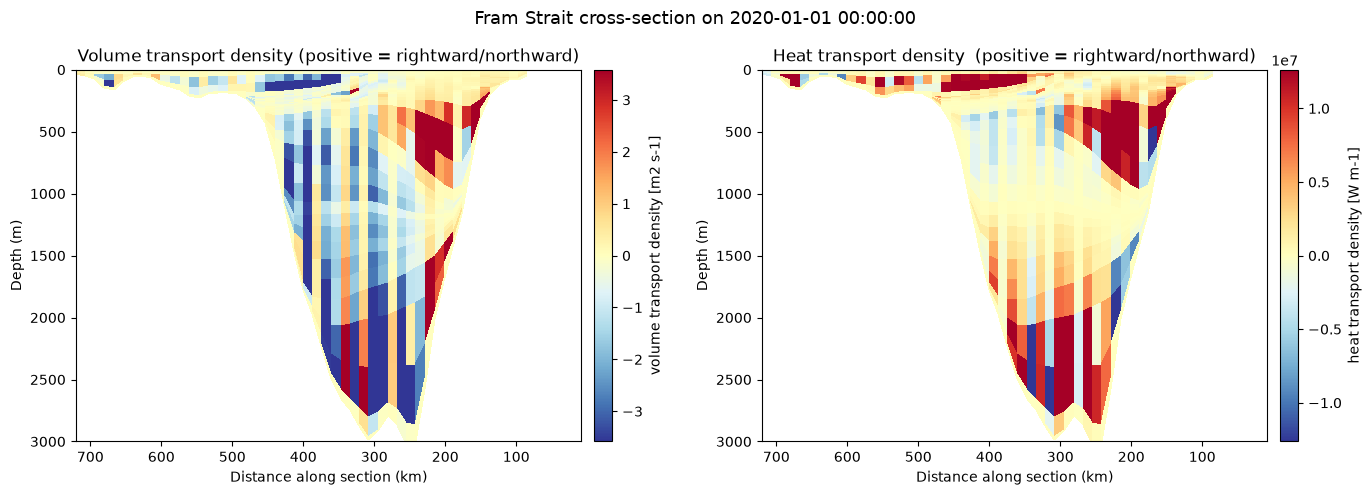

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

xhycom.section_plot(
    sec_flux0, "flux_density", 
    ax=axes[0],
    depth_max=3000, 
    flip_x=True, # flip section orientation to west to east
    cmap="RdYlBu_r",
    center_zero=True,
    title="Volume transport density (positive = rightward/northward)",
)

xhycom.section_plot(
    sec_flux0, 
    "heat_flux_density", 
    ax=axes[1],
    depth_max=3000, 
    flip_x=True, # flip section orientation to west to east
    cmap="RdYlBu_r",
    center_zero=True,
    title="Heat transport density  (positive = rightward/northward)",
)

fig.suptitle(f"Fram Strait cross-section on {sec0.time.values.item()}", fontsize=13)
plt.tight_layout()

In the left plot, you can see 
* the Atlantic water moving northward in the eastern and upper part of the section;
* the East Greenland Current flowing southward in the western part of the section

To compare these results against a reanalysis product such as GLORYS, see [comparison_transects_transports.ipynb](comparison_transects_transports.ipynb).